# Model calibration: Effects of to BdJEL423 *Discoglossus pictus* juveniles

## Notebook setup

In [1]:
using DrWatson
@quickactivate "."
#using Pkg; Pkg.instantiate()

In [2]:
const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVETAG_CORRECTION_FACTORS = "Discoglossus_24D_exp2_control"
const SAVETAG = "Discoglossus_BdBE3_exp3"

using Revise
includet(scriptsdir("ModelFitting_Discoglossus_BdBE3_exp3.jl"));

In [3]:
using Pkg
Pkg.status("AmphiDEB") # show version of AmphiDEB used

Status `C:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\Project.toml`
  [eee04faf] AmphiDEB v0.3.7 `https://github.com/simonhansul/amphideb.git#main`


In [4]:
Pkg.status("EcotoxSystems") # show version of EcotoxSystems used

Status `C:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\Project.toml`
  [a070e96f] EcotoxSystems v0.2.3 `https://github.com/simonhansul/ecotoxsystems.jl.git#main`


## Technical notes 

The priors for Bd growth parameters were set manually. <br> 
Using specific priors for the most influential Bd growth/infection parameters is extremely helpful for this calibration problem, 
due to the correlation between Bd growth and effect parameters. <br>
The plotting functions are set up to display the distributions of juvenile wet mass over individuals, but the model is fitted to averages. 

## Simulation setup

In [5]:
data = load_data_exp3_Bd()

OrderedDict{Symbol, DataFrame} with 3 entries:
  :juveniles_raw        => 60×11 DataFrame…
  :juveniles_aggregated => 4×8 DataFrame…
  :bdloads              => 1×9 DataFrame…

┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase C:\Users\shansul\.julia\packages\SciMLBase\wfZCo\src\performance_warnings.jl:33
┌ Info: 
│         Estimating 6 parameters: 
│         ["pth.gamma", "pth.eta", "pth.sigma1", "spc.Chi", "spc.E_P[2]", "spc.B_P[2]"]
│         
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found in data key juveniles_raw. Assuming uniform weights.
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:98
┌ Info: No column `observation_weight` found in data key juveniles_aggregated. Assuming uniform weights.
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:9

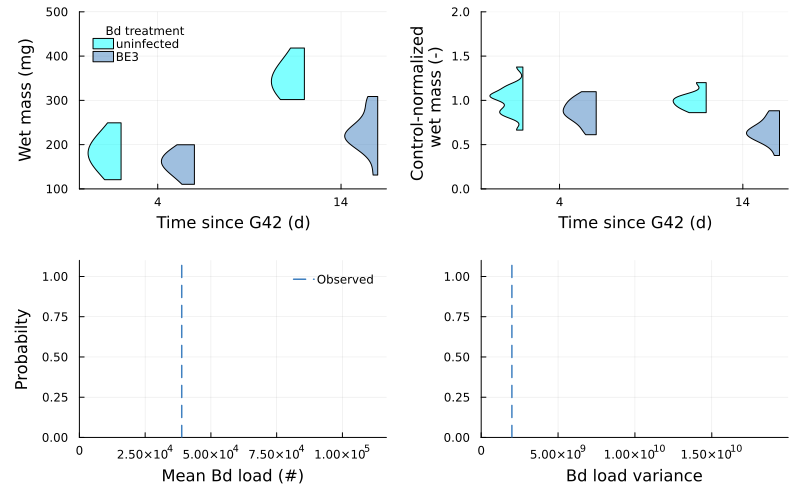

In [6]:
f = setup_modelfit_exp3_Bd("M")
f.plot_data()

## Prior check

With the model fit set up, we can perform a prior predictive check and compare thie range of prior predictions with the observations.

┌ Info: #### ---- Evaluating 10 prior samples on 8 threads ---- ####
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\prior_check.jl:13
Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


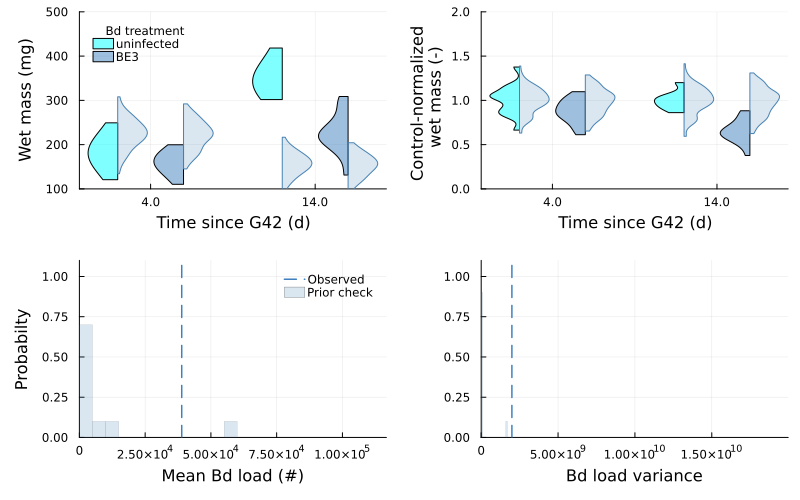

In [13]:
prior_check = prior_predictive_check(f; n = 10);

plt = f.plot_data()
plot_sims_Bd!(plt, prior_check.predictions; label = "Prior check")

plt

From the prior check, we can retrieve some preliminary parameter estimates.

In [14]:
p_opt = prior_check.samples[argmin(prior_check.losses)];

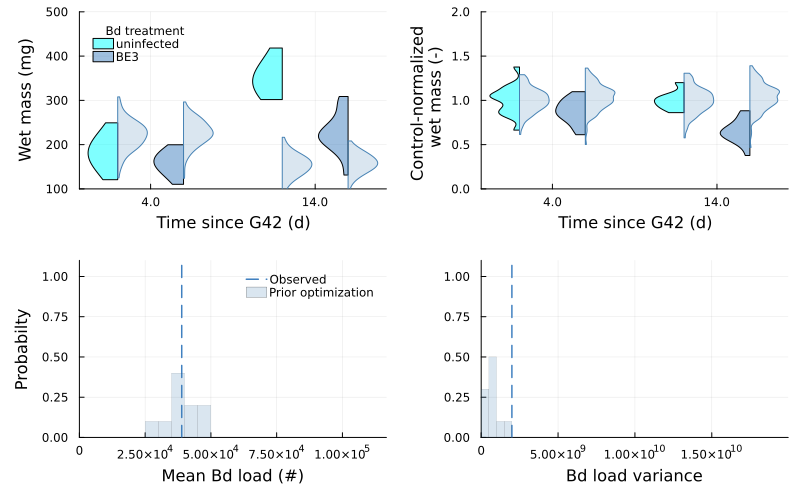

In [15]:
sim_opt = [f.simulator(p_opt) for _ in 1:10];
plt = f.plot_data()
plot_sims_Bd!(plt, sim_opt; label = "Prior optimization")
plt

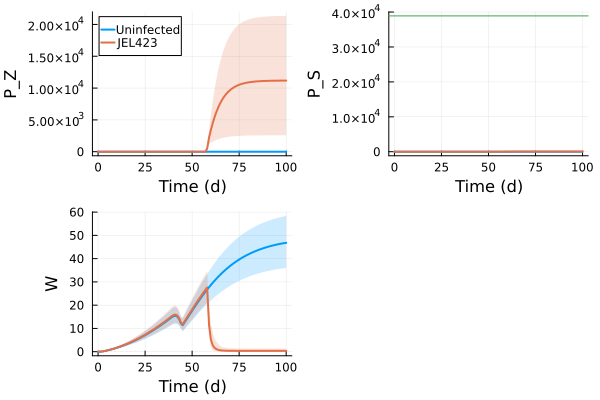

In [23]:
sim_opt = @replicates f.simulator(p_opt, return_raw = true) 10

@df sim_opt plot(
    groupedlineplot(ylabel = "P_Z", :t, :P_Z, :treatment_id), 
    groupedlineplot(ylabel = "P_S", :t, :P_S, :treatment_id), 
    groupedlineplot(ylabel = "W", :t, :S .+ :E_mt, :treatment_id), 
    xlabel = "Time (d)", leg = [:topleft false false], label = ["Uninfected" "JEL423"], 
    fillalpha = .2, lw = 2
)

hline!(f.data[:bdloads].load_mean, subplot = 2)


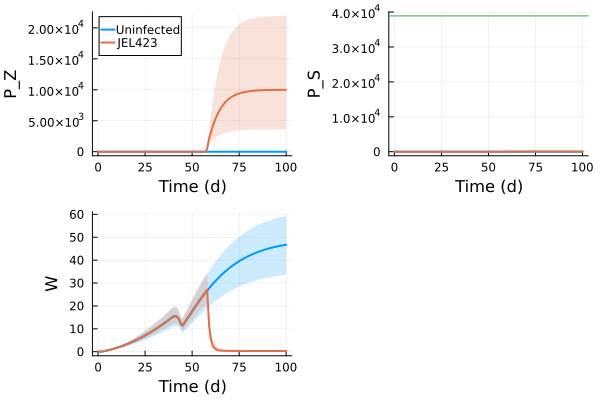

In [18]:
sim_opt = @replicates f.simulator(p_opt, return_raw = true) 10

@df sim_opt plot(
    groupedlineplot(ylabel = "P_Z", :t, :P_Z, :treatment_id), 
    groupedlineplot(ylabel = "P_S", :t, :P_S, :treatment_id), 
    groupedlineplot(ylabel = "W", :t, :S .+ :E_mt, :treatment_id), 
    xlabel = "Time (d)", leg = [:topleft false false], label = ["Uninfected" "JEL423"], 
    fillalpha = .2, lw = 2
)

hline!(f.data[:bdloads].load_mean, subplot = 2)

## Parameter inference

In [ ]:
savetag = SAVETAG
lowsettings = ( # eta 2 minutes
    :n_init => 100,
    :n => 100,
    :q_dist => 0.1, 
    :t_max => 3, 
    :evals_per_sample => 1
)

highsettings = ( # eta 2h
    :n => 10_000, 
    :q_dist => 0.1, 
    :t_max => 5,
    :evals_per_sample => 1
)

savedir = datadir("sims")
savetag = SAVETAG
continue_from = nothing

@time pmchist = run_PMC!(
    f; 
    highsettings...,
    savedir = savedir,
    savetag = savetag, 
    paramlabels = paramlabels, 
    continue_from = continue_from
);

┌ Info: Saving results to c:\Users\shansul\Documents\AmphiDEBResearch\WP02_TKTD\data\sims\Discoglossus_BdBE3_exp3
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\populationmontecarlo.jl:119
┌ Info: #### ---- Evaluating 10000 initial samples on 8 threads ---- ####
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\populationmontecarlo.jl:132
Progress:  78%|████████████████████████████████         |  ETA: 0:09:11Excessive output truncated after 524453 bytes.

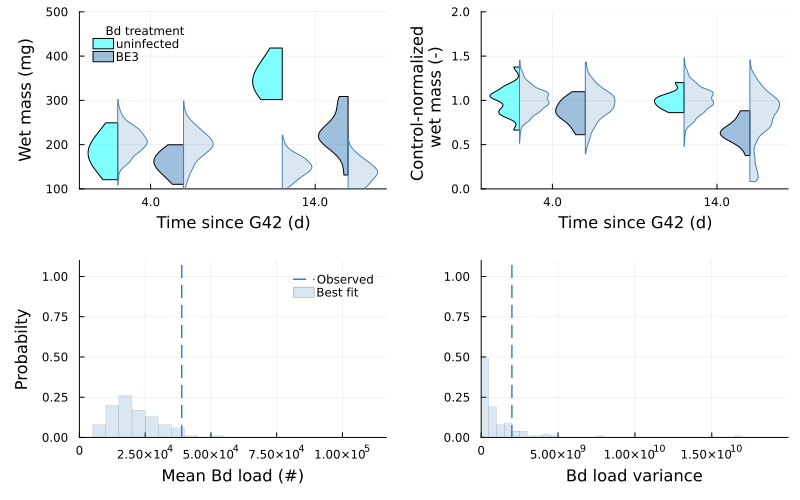

"c:\\Users\\shansul\\Documents\\AmphiDEBResearch\\WP02_TKTD\\data\\sims\\Discoglossus_BdBE3_exp3\\VPC_posterior_bestfit.png"

In [31]:
@info "#### ---- Best fit ---- ####"

let plt = f.plot_data()

    p_opt = f.accepted[:,argmin(vec(f.losses))]
    sim_opt = [f.simulator(p_opt) for _ in 1:100]

    plot_sims_exp2_Bd!(plt, sim_opt, label = "Best fit")
    display(plt)
    
    if !isnothing(savetag)
        savefig(plot(plt, dpi = 400), datadir("sims", "$(savetag)", "VPC_posterior_bestfit.png"))
    end
end

In [32]:
import Plots:plot
plot(dist::Hyperdist) = plot(dist.dist)

plot (generic function with 5 methods)

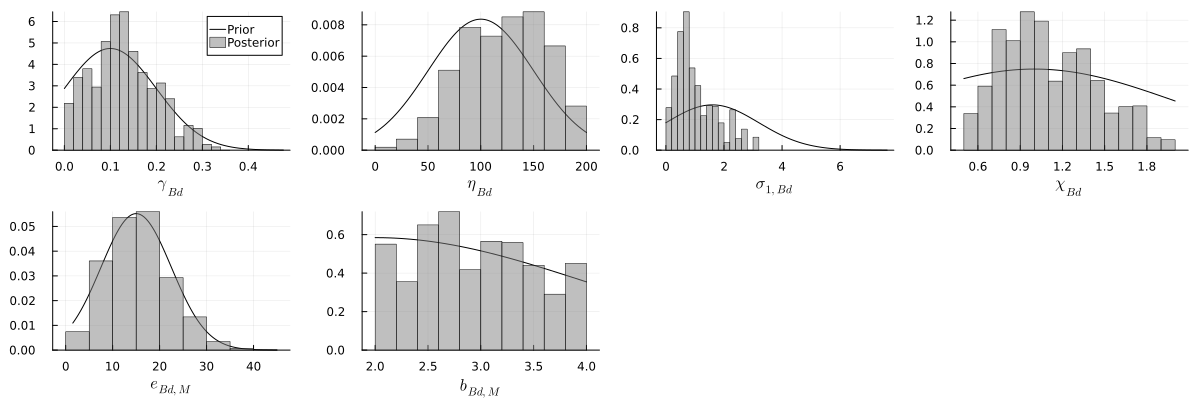

"c:\\Users\\shansul\\Documents\\AmphiDEBResearch\\WP02_TKTD\\data\\sims\\Discoglossus_BdBE3_exp3\\marginal_posteriors.png"

In [33]:
@info "#### ---- Marginal posteriors ---- ####"

let plt, num_params = length(f.prior.dists), num_cols = 4, num_rows = Int(ceil(num_params / num_cols))

    plt = plot(
        plot.(f.prior.dists, color = :black)..., 
        layout = (num_rows, num_cols), 
        leg = hcat(vcat(true, repeat([false], num_params-1))...), 
        label = "Prior", 
        size = (1200,200*num_rows), bottommargin = 5mm
        )

        
    for (i,param) in enumerate(f.prior.labels)

        histogram!(
            plt, subplot = i, 
            f.accepted[i,:], weights = Weights(vec(f.weights)), 
            xlabel = param in keys(paramlabels) ? paramlabels[param] : param, 
            normalize = :pdf, label = "Posterior", color = :gray, lw = 0.5, fillalpha = .5
            )
    end

    display(plt)
    
    if !isnothing(savetag)
        savefig(plot(plt, dpi = 400), datadir("sims", "$(savetag)", "marginal_posteriors.png"))
    end
end

In [34]:
generate_posterior_summary(
    f; 
    tex = true,
    paramlabels = paramlabels,
    savedir = savedir,
    savetag = savetag
) |> display

Row,param,best_fit,median,q05,q95
,String,Float64,Float64,Float64,Float64
1,pth.gamma,0.0444886,0.124106,0.0239861,0.261813
2,pth.eta,167.387,125.578,55.7655,182.416
3,pth.sigma1,1.34927,0.826793,0.188123,2.48847
4,spc.Chi,1.27155,1.06091,0.6398,1.7325
5,spc.E_P[2],19.608,15.2335,5.56645,27.5694
6,spc.B_P[2],2.57774,2.90658,2.07734,3.90674
